# Human-in-the-Loop

Human-in-the-Loop(HITL)는 AI가 모든 작업을 자동으로 처리하지 않고, 중요한 판단이 필요한 지점에서 사람이 검토하거나 결정하도록 하는 방식이다.

다음과 같은 상황에 사람의 개입이 필요하다.

- 결제, 삭제, 이메일 발송처럼 되돌리기 어려운 작업의 승인
- LLM이 생성한 답변이나 문서의 검토와 수정
- 작업에 필요한 정보가 부족할 때 추가 입력 요청

```text
AI 작업 수행 → 사람의 판단이 필요한 지점에서 중단 → 검토·입력 → 작업 재개
```

LangGraph에서는 그래프 실행을 중단하고, 사람의 입력을 받은 뒤 재개하는 방식으로 HITL을 구현한다.

In [5]:
from typing import Annotated, TypedDict

from dotenv import load_dotenv
from langchain_core.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt
import operator
from typing import Literal
from IPython.display import Image, display

from pydantic import BaseModel, Field
from langgraph.graph import END

load_dotenv()

MODEL_NAME = "gemini-3.6-flash"

### `interrupt()`

`interrupt(value)`는 노드나 Tool 내부에서 호출할 수 있다. 실행이 해당 코드에 도달하면 그래프를 중단하고 `value`를 호출자에게 반환한다. Checkpointer는 당시의 그래프 state와 중단된 작업을 기록한다. 같은 `thread_id`로 결정을 전달하면 노드나 Tool을 처음부터 다시 실행하고, `interrupt()`가 그 결정을 반환한 뒤 다음 코드로 진행한다.

In [5]:
@tool(parse_docstring=True)
def send_payment(amount: int, recipient: str) -> str:
    """수신자에게 결제를 실행한다.

    Args:
        amount: 결제 금액
        recipient: 수신자 이름
    """
    # 재개 시 Tool이 처음부터 실행되므로 이 메시지는 다시 출력된다.
    print(f"결제 요청 검토: {recipient}, {amount:,}원")

    decision = interrupt(
        {
            "question": "이 결제를 실행하시겠습니까?",
            "tool": "send_payment",
            "args": {"amount": amount, "recipient": recipient},
        }
    )

    if decision["action"] == "reject":
        reason = decision.get("reason", "사유 없음")
        return f"결제가 취소되었습니다. 사유: {reason}"

    # 결제처럼 부작용이 있는 작업은 interrupt() 뒤에서 실행한다.
    return f"{recipient}에게 {amount:,}원 결제 완료."

### 그래프 구성

Agent가 Tool 호출을 만들면 `ToolNode`가 해당 Tool을 실행한다. `send_payment`는 함수 내부의 `interrupt()`에서 중단된다. 그래프 state와 중단된 작업을 기록하는 Checkpointer, 실행을 구분하는 `thread_id`가 있어야 나중에 재개할 수 있다.

In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


tools = [send_payment]
llm = ChatGoogleGenerativeAI(model=MODEL_NAME).bind_tools(tools)


def agent(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


builder = StateGraph(State)
builder.add_node("agent", agent)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "agent")
builder.add_conditional_edges("agent", tools_condition)
builder.add_edge("tools", "agent")

graph = builder.compile(checkpointer=MemorySaver())

### 중단에 사용되는 세 가지 값

| 구분 | 역할 |
|------|------|
| 그래프 state | 노드들이 읽고 수정하는 내부 실행 상태 |
| interrupt payload | 호출자가 검토할 질문, Tool 이름과 인자 |
| resume value | 승인자가 그래프에 돌려주는 결정 |

`interrupt(value)`의 `value`는 `__interrupt__`를 통해 호출자에게 전달된다. payload와 resume 값에는 Checkpointer가 저장할 수 있는 문자열, 숫자, 목록, 딕셔너리 같은 JSON 직렬화 가능 값을 사용한다.

```text
첫 번째 요청: graph.invoke(작업, config)
             → Tool 내부 interrupt()에서 중단
             → payload 반환 및 그래프 실행 정보 기록

두 번째 요청: graph.invoke(Command(resume=결정), 같은 config)
             → 같은 thread_id의 상태 복원
             → 결정이 interrupt()의 반환값이 되어 실행 재개
```

### Tool 실행 전 중단

첫 번째 `invoke()`는 결제를 실행하지 않는다. `send_payment`의 `interrupt()`가 전달한 질문과 Tool 인자가 `__interrupt__`에 담겨 반환된다. Checkpointer에는 그래프 state와 중단된 작업이 기록된다.

In [10]:
thread_id = "payment-2"
config = {"configurable": {"thread_id": thread_id}}

result = graph.invoke(
    {"messages": [("user", "홍길동에게 50000원 결제해줘")]},
    config,
)

request = result["__interrupt__"][0].value
print(f"질문: {request['question']}")
print(f"Tool: {request['tool']}")
print(f"인자: {request['args']}")
print(f"다음 노드: {graph.get_state(config).next}")

결제 요청 검토: 홍길동, 50,000원
질문: 이 결제를 실행하시겠습니까?
Tool: send_payment
인자: {'amount': 50000, 'recipient': '홍길동'}
다음 노드: ('tools',)


### 승인 값으로 재개

승인자는 웹 화면이나 API 등을 통해 결정을 내린다. 호출자는 같은 `thread_id`와 `Command(resume=...)`를 사용해 그 결정을 전달한다. `resume` 값은 Tool 내부 `interrupt()`의 반환값이 된다.

재개할 때 `ToolNode`와 Tool 함수는 처음부터 다시 실행되지만, `interrupt()`는 다시 중단하지 않고 전달받은 값을 반환한다.

In [11]:
result = graph.invoke(
    Command(resume={"action": "approve"}),
    config,
)

print(result["messages"][-1].text)

결제 요청 검토: 홍길동, 50,000원
홍길동님에게 50,000원 결제가 완료되었습니다.


### 거절과 사유 전달

새로운 실행을 중단한 뒤 `resume` 값에 `reject`와 사유를 담아 전달하면 Tool이 결제를 수행하지 않고 취소 결과를 반환한다.

In [13]:
config2 = {"configurable": {"thread_id": "payment-3"}}

result = graph.invoke(
    {"messages": [("user", "김철수에게 100000원 결제해줘")]},
    config2,
)

request = result["__interrupt__"][0].value
print(f"질문: {request['question']}")
print(f"Tool: {request['tool']}")
print(f"인자: {request['args']}")
print(f"다음 노드: {graph.get_state(config2).next}")

결제 요청 검토: 김철수, 100,000원
질문: 이 결제를 실행하시겠습니까?
Tool: send_payment
인자: {'amount': 100000, 'recipient': '김철수'}
다음 노드: ('tools',)


In [14]:
result = graph.invoke(
    Command(
        resume={"action": "reject", "reason": "금액을 다시 확인해야 합니다."}
    ),
    config2,
)

print(result["messages"][-1].text)

결제 요청 검토: 김철수, 100,000원
김철수님에게 100,000원 결제 요청을 진행했으나, **금액 확인이 필요하여 결제가 취소되었습니다.** 

결제 금액(100,000원)을 다시 확인하신 후 재시도해 주세요.


### 직접 승인 또는 거절하기

`input()`으로 승인 여부를 입력하고 중단된 그래프를 재개한다. 실제 서비스에서는 웹 화면이나 API로 결정을 전달한다.

In [17]:
input_config = {"configurable": {"thread_id": "payment-input"}}

# client에서 요청이 왔습니다.
result = graph.invoke(
    {"messages": [("user", "이영희에게 70000원 결제해줘")]},
    input_config,
)

# 서버에서 해당 tool을 사용하기 위해서 허락을 맡아야 하는 상황입니다.

request = result["__interrupt__"][0].value

# 아래 request에 들어있는 정보를 바탕으로 사용자에게 허락을 맡습니다.
# client는 지금 print()된 것들을 보고있습니다.
print(f"질문: {request['question']}")
print(f"인자: {request['args']}")

# client는 승인을 할지, 거절을 할지 정합니다.
# 정하게 되면, 해당 정보가 우리의 server로 오게 됩니다.
answer = input("결제를 승인하시겠습니까? (y/n): ").strip().lower()


# 해당 정보를 서버에서 처리합니다.
if answer == "y":
    decision = {"action": "approve"}
else:
    reason = input("거절 사유를 입력하세요: ")
    decision = {"action": "reject", "reason": reason}

result = graph.invoke(
    Command(resume=decision),
    input_config,
)
print(result["messages"][-1].text)

결제 요청 검토: 이영희, 70,000원
질문: 이 결제를 실행하시겠습니까?
인자: {'amount': 70000, 'recipient': '이영희'}
결제 요청 검토: 이영희, 70,000원
이영희님에게 70,000원 결제를 시도하였으나 취소되었습니다.


### 서버에서의 요청 흐름

실제 서비스에서는 서버가 승인될 때까지 하나의 요청을 계속 연결해 두지 않는다. 첫 번째 API 요청은 `interrupt()`에서 중단된 정보와 `thread_id`를 응답하고 종료된다. 사용자가 화면에서 승인하거나 거절하면 두 번째 API 요청이 같은 `thread_id`와 `Command(resume=...)`를 전달해 저장된 실행을 재개한다.
```text
Client                              Server / Graph
  │
  │  POST /chat
  │  { message: "..." }
  ├──────────────────────────────────▶
  │                                   │ Graph 실행
  │                                   │ thread_id = "abc123"
  │                                   │ ↓
  │                                   │ interrupt(...)
  │                                   │ ⏸ 실행 중단
  │
  │  response
  │  {
  │    thread_id: "abc123",
  │    interrupt: {
  │      question: "이 작업을 실행할까요?"
  │    }
  │  }
  ◀───────────────────────────────────┤
  │
  │  thread_id = "abc123" 저장
  │
  │  사용자에게 확인 UI 표시
  │
  │    [승인] [거절]
  │
  │  POST /resume
  │  {
  │    thread_id: "abc123",
  │    action: "approve",        ← 승인
  │    // action: "reject"       ← 거절
  │  }
  ├──────────────────────────────────▶
  │                                   │ thread_id로
  │                                   │ 중단된 Graph 식별
  │                                   │ ↓
  │                                   │ Command(
  │                                   │   resume={...}
  │                                   │ )
  │                                   │ ↓
  │                                   │ 실행 재개
  │                                   │ ↓
  │                                   │ action에 따라 분기
  │                                   │ ↓
  │                                   │ Graph 완료
  │
  │  response
  │  "처리가 완료되었습니다."
  ◀───────────────────────────────────┤
  ```

### Client와 Server 함수로 구분하기

노트북 안에서 Client와 Server가 통신하는 상황을 함수로 표현한다. `post_chat()`과 `post_resume()`은 Server의 API endpoint 역할을 한다. Client는 Server 내부의 LangGraph 코드를 직접 다루지 않고, endpoint 함수를 호출하고 응답을 사용한다.

In [ ]:
# Backend: POST /chat endpoint
# 이 코드는 반드시 interrupt이 있다는 가정 하에 만들어졌습니다.
def post_chat(message: str, thread_id: str) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke(
        {"messages": [("user", message)]},
        config,
    )

    request = result["__interrupt__"][0].value
    return {
        "thread_id": thread_id,
        "question": request["question"],
        "tool": request["tool"],
        "args": request["args"],
    }


# Backend: POST /resume endpoint
def post_resume(thread_id: str, decision: dict) -> dict:
    config = {"configurable": {"thread_id": thread_id}}
    result = graph.invoke(
        Command(resume=decision),
        config,
    )

    return {"message": result["messages"][-1].text}

### Client에서 승인 요청 처리하기

Client는 사용자 요청을 Server에 전달하고, 응답으로 받은 질문을 화면에 표시한다. 사용자의 승인 또는 거절 결정을 다시 Server에 전달한 뒤 최종 결과를 표시한다.

In [21]:
# Frontend: 사용자 요청을 Backend에 전달
response = post_chat(
    message="박민수에게 30000원 결제해줘",
    thread_id="payment-client-server",
)

# Frontend: 승인 화면 표시 및 사용자 입력 처리
print(response["question"])
print(response["args"])

answer = input("결제를 승인하시겠습니까? (y/n): ").strip().lower()
if answer == "y":
    decision = {"action": "approve"}
else:
    reason = input("거절 사유를 입력하세요: ")
    decision = {"action": "reject", "reason": reason}

# Frontend: 사용자 결정을 Backend에 전달하고 결과 표시
final_response = post_resume(
    thread_id=response["thread_id"],
    decision=decision,
)
print(final_response["message"])

결제 요청 검토: 박민수, 30,000원
이 결제를 실행하시겠습니까?
{'amount': 30000, 'recipient': '박민수'}
결제 요청 검토: 박민수, 30,000원
박민수님에게 30,000원 결제가 취소되었습니다. (사유: 싫어서)


### 실습: 게시글 발행 승인하기

`publish_post(title, content)` Tool을 만들고, 게시글을 발행하기 전에 사용자의 승인을 받는 흐름을 구현한다. 승인과 거절을 각각 실행해 결과를 확인한다.

In [ ]:
@tool
def publish_post(title: str, content: str) -> str:
    """게시글을 발행한다."""
    # TODO: 게시글 발행 전 승인을 받는 HITL 흐름을 구현하세요.
    print('게시글 발행 검토를 해주세요.')
    decision = interrupt(
        {
            "question": "이 게시글을 공개하겠습니까?",
            "tool": "publish_post",
            "args": {"title": title, "content": content},
        }
    )


    if decision['action'] == 'approve':
        return ('게시글 발행 성공!')

    elif decision['action'] == 'reject':
        return ('게시글 발행 실패!')


In [23]:
from langchain.agents import create_agent
tools = [publish_post]
agent = create_agent(model=llm, tools=tools, checkpointer=MemorySaver())


In [34]:
# 1. invoke()
thread_id = "thread-2"
config = {"configurable": {"thread_id": thread_id}}

result = agent.invoke({"messages": [("human", "점심식사에 대한 게시글을 발행해줘.")]}, config=config)

print(result["__interrupt__"][0].value)

# 2. 결과가 interupt되어서 우리에게 다시 되묻는 과정이 있다.

게시글 발행 검토를 해주세요.
{'question': '이 게시글을 공개하겠습니까?', 'tool': 'publish_post', 'args': {'title': '[일상] 오늘 점심 뭐 드셨나요? 맛있는 점심식사로 오후도 화이팅!', 'content': '안녕하세요! 오늘 점심은 어떤 맛있는 메뉴로 드셨나요?\n\n바쁜 일상 속에서도 든든하고 맛있는 점심 한 끼는 남은 하루를 활기차게 보낼 수 있는 큰 힘이 됩니다. \n\n다들 영양 가득한 식사 하셨기를 바라며, 나른해지기 쉬운 오후 시간도 즐겁고 힘차게 보내세요! \n\n#점심메뉴 #맛점 #일상 #오늘의식사'}}


In [35]:
user_input = input('할꺼면 - y, 안할꺼면 - n')

# 승인
if user_input == 'y':
    action = 'approve'

# 거절
elif user_input == 'n':
    action = 'reject'

result = agent.invoke(Command(resume={'action' : action}), config=config)

print(result)

게시글 발행 검토를 해주세요.
{'messages': [HumanMessage(content='점심식사에 대한 게시글을 발행해줘.', additional_kwargs={}, response_metadata={}, id='c34f30a1-fe3f-462c-9046-7b59baae24cb'), AIMessage(content=[], additional_kwargs={'function_call': {'name': 'publish_post', 'arguments': '{"title": "[\\uc77c\\uc0c1] \\uc624\\ub298 \\uc810\\uc2ec \\ubb50 \\ub4dc\\uc168\\ub098\\uc694? \\ub9db\\uc788\\ub294 \\uc810\\uc2ec\\uc2dd\\uc0ac\\ub85c \\uc624\\ud6c4\\ub3c4 \\ud654\\uc774\\ud305!", "content": "\\uc548\\ub155\\ud558\\uc138\\uc694! \\uc624\\ub298 \\uc810\\uc2ec\\uc740 \\uc5b4\\ub5a4 \\ub9db\\uc788\\ub294 \\uba54\\ub274\\ub85c \\ub4dc\\uc168\\ub098\\uc694?\\n\\n\\ubc14\\uc05c \\uc77c\\uc0c1 \\uc18d\\uc5d0\\uc11c\\ub3c4 \\ub4e0\\ub4e0\\ud558\\uace0 \\ub9db\\uc788\\ub294 \\uc810\\uc2ec \\ud55c \\ub07c\\ub294 \\ub0a8\\uc740 \\ud558\\ub8e8\\ub97c \\ud65c\\uae30\\ucc28\\uac8c \\ubcf4\\ub0bc \\uc218 \\uc788\\ub294 \\ud070 \\ud798\\uc774 \\ub429\\ub2c8\\ub2e4. \\n\\n\\ub2e4\\ub4e4 \\uc601\\uc591 \\uac00\\ub4dd\\ud55c \\u

In [36]:
for r in result['messages']:
    print(r.type)
    print(r.text)

human
점심식사에 대한 게시글을 발행해줘.
ai

tool
게시글 발행 실패!
ai
점심식사에 대한 게시글 발행을 시도했으나 실패했습니다. 잠시 후 다시 시도해 주시거나 시스템 상태를 확인해 주세요.


### 추가 실습: 실행 계획 검토하기

아래 코드는 HITL을 추가할 수 있도록 실행 과정을 단순화한 Plan-and-Execute 그래프다.

Planner가 만든 계획을 실행 전에 검토한다. 승인하면 Executor가 계획을 실행하고, 거절하면 추가 의견을 Planner에 전달해 계획을 다시 만든다. 수정된 계획은 다시 검토받는다.

```text
Planner → 계획 검토(HITL)
            ├─ 승인 → Executor
            └─ 거절 + 추가 의견 → Planner → 계획 검토(HITL)
```

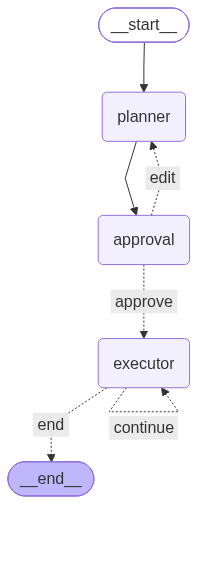

In [ ]:


class SimplePlanState(TypedDict):
    task: str
    plan: list[str]
    completed: Annotated[list[str], operator.add]
    action: str
    feedback: str

class SimplePlan(BaseModel):
    steps: list[str] = Field(description="순서대로 수행할 단계")


simple_planner = ChatGoogleGenerativeAI(model=MODEL_NAME).with_structured_output(SimplePlan)


def simple_plan_step(state: SimplePlanState):
    task = state['task']
    if state.get('feedback'):
        task += f'기존 계획 : {state.get('plan')} 다음 피드백을 바탕으로 작성해줘. {state.get('feedback')}'
    result = simple_planner.invoke(
        f"{task}\n실행 계획을 3단계 이내로 작성하세요."
    )
    return {"plan": result.steps}


def simple_execute_step(state: SimplePlanState):
    step = state["plan"][0]
    return {
        "plan": state["plan"][1:],
        "completed": [f"완료: {step}"],
    }


def route_execution(state: SimplePlanState):
    return "continue" if state["plan"] else "end"

####################

def human_approval(state: SimplePlanState):
    # interrupt해서 사용자한테 해당 plan을 지속할건지, 재작성 할건지 정함.
    decision = interrupt({
        # 사용자한테 전달할 정보.
        'plan' : state['plan'],
        'question' : "이 계획으로 실행할까요?"

    })
    return {
        'action' : decision['action'], 
        'feedback' : decision.get('feedback', "")
        }

def route_human_appoval(state: SimplePlanState):
    # 사용자가 interrupt한 부분에 대해서
    # 결정지은 값에 대해서 execute할건지 다시 plan할건지 정하는 router.
    action = state['action']

    if action == 'edit':
        return 'edit'
    return 'approve'

base_builder = StateGraph(SimplePlanState)
base_builder.add_node("planner", simple_plan_step)
base_builder.add_node("executor", simple_execute_step)
base_builder.add_node("approval", human_approval)

base_builder.add_edge(START, "planner")
base_builder.add_edge("planner", "approval")
base_builder.add_conditional_edges(
    "approval",
    route_human_appoval,
    {
        'edit' : 'planner',
        'approve' : 'executor'
    }
)

base_builder.add_conditional_edges(
    "executor",
    route_execution,
    {"continue": "executor", "end": END},
)

hitl_graph = base_builder.compile(checkpointer=MemorySaver())

from IPython.display import Image, display

display(Image(hitl_graph.get_graph().draw_mermaid_png()))

In [38]:
result = hitl_graph.invoke(
    {
        "task": "팀 회의 준비하기"
    }
)
print(*result["completed"], sep="\n")

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


완료: 회의 목적 정의 및 안건 작성하기
완료: 회의 일정 확정 및 참석자에게 사전 자료 공유하기
완료: 회의 장소 및 필요 장비 점검하기


In [ ]:
# TODO: Plan-and-Execute 그래프에 HITL을 추가하세요.

### 실행

HITL을 추가한 그래프를 실행해 초기 계획을 확인한다.

In [51]:
config = {"configurable": {"thread_id": "plan-review-2"}}

result = hitl_graph.invoke(
    {
        "task": "팀 회의 준비하기"
    },
    config
)
print(result["__interrupt__"][0].value)

{'plan': ['회의 안건 및 목표 정의하기', '회의 일정 확정 및 참석자에게 안내하기', '회의 자료 작성 및 필요한 시스템 사전 점검하기'], 'question': '이 계획으로 실행할까요?'}


추가 의견을 전달하고 수정된 계획을 확인한다.

In [52]:
result = hitl_graph.invoke(
    Command(
        resume={
            'action' : 'edit',
            'feedback' : input()
        }
    ),
    config,
)
print(result["__interrupt__"][0].value)

{'plan': ['회의 안건 및 세부 목표를 명확히 정의하고 주요 논의 항목 사전 정리하기', '회의 일정을 확정하여 참석자에게 안내하고 사전 수렴 의견 및 참석 여부 확인하기', '회의 자료를 상세히 작성하고 회의 시스템 및 진행 환경 사전 점검하기'], 'question': '이 계획으로 실행할까요?'}


수정된 계획을 승인하고 실행 결과를 확인한다.

In [53]:
result = hitl_graph.invoke(
    Command(resume={
        'action' : 'approve'
    }),
    config,
)
print(*result["completed"], sep="\n")

완료: 회의 안건 및 세부 목표를 명확히 정의하고 주요 논의 항목 사전 정리하기
완료: 회의 일정을 확정하여 참석자에게 안내하고 사전 수렴 의견 및 참석 여부 확인하기
완료: 회의 자료를 상세히 작성하고 회의 시스템 및 진행 환경 사전 점검하기


In [58]:
history = hitl_graph.get_state_history(config)


for state in history:
    print(state)

StateSnapshot(values={'task': '팀 회의 준비하기', 'plan': [], 'completed': ['완료: 회의 안건 및 세부 목표를 명확히 정의하고 주요 논의 항목 사전 정리하기', '완료: 회의 일정을 확정하여 참석자에게 안내하고 사전 수렴 의견 및 참석 여부 확인하기', '완료: 회의 자료를 상세히 작성하고 회의 시스템 및 진행 환경 사전 점검하기'], 'action': 'approve', 'feedback': ''}, next=(), config={'configurable': {'thread_id': 'plan-review-2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b0d41-c0ac-6701-8007-587edf86f315'}}, metadata={'source': 'loop', 'step': 7, 'parents': {}}, created_at='2026-09-15T07:07:27.521951+00:00', parent_config={'configurable': {'thread_id': 'plan-review-2', 'checkpoint_ns': '', 'checkpoint_id': '1f1b0d41-c0aa-60c6-8006-8bd84d9fb241'}}, tasks=(), interrupts=())
StateSnapshot(values={'task': '팀 회의 준비하기', 'plan': ['회의 자료를 상세히 작성하고 회의 시스템 및 진행 환경 사전 점검하기'], 'completed': ['완료: 회의 안건 및 세부 목표를 명확히 정의하고 주요 논의 항목 사전 정리하기', '완료: 회의 일정을 확정하여 참석자에게 안내하고 사전 수렴 의견 및 참석 여부 확인하기'], 'action': 'approve', 'feedback': ''}, next=('executor',), config={'configurable': {'thread_id': 'plan-review-2', 'checkpoin

In [60]:
for state in hitl_graph.get_state_history(config):
    values = state.values
    next_node = state.next
    plan = values.get('plan', "")
    print(next_node, plan)

() []
('executor',) ['회의 자료를 상세히 작성하고 회의 시스템 및 진행 환경 사전 점검하기']
('executor',) ['회의 일정을 확정하여 참석자에게 안내하고 사전 수렴 의견 및 참석 여부 확인하기', '회의 자료를 상세히 작성하고 회의 시스템 및 진행 환경 사전 점검하기']
('executor',) ['회의 안건 및 세부 목표를 명확히 정의하고 주요 논의 항목 사전 정리하기', '회의 일정을 확정하여 참석자에게 안내하고 사전 수렴 의견 및 참석 여부 확인하기', '회의 자료를 상세히 작성하고 회의 시스템 및 진행 환경 사전 점검하기']
('approval',) ['회의 안건 및 세부 목표를 명확히 정의하고 주요 논의 항목 사전 정리하기', '회의 일정을 확정하여 참석자에게 안내하고 사전 수렴 의견 및 참석 여부 확인하기', '회의 자료를 상세히 작성하고 회의 시스템 및 진행 환경 사전 점검하기']
('planner',) ['회의 안건 및 목표 정의하기', '회의 일정 확정 및 참석자에게 안내하기', '회의 자료 작성 및 필요한 시스템 사전 점검하기']
('approval',) ['회의 안건 및 목표 정의하기', '회의 일정 확정 및 참석자에게 안내하기', '회의 자료 작성 및 필요한 시스템 사전 점검하기']
('planner',) 
('__start__',) 


### 추가 실습: 필요한 정보 질문하기

사용자 요청에 필요한 정보가 부족할 때 LLM이 추가 질문을 생성하는 흐름을 구현한다. 각 질문에는 객관식 선택지를 제공하고, 사용자가 직접 답변할 수도 있도록 한다. 답변을 받은 뒤에는 원래 요청을 수행하는 대신 사용자 답변을 정리한다.

- 예시 요청: 다음 주말 국내 여행을 계획하고 있습니다. 제 취향에 맞는 1박 2일 일정을 추천해 주세요.
- 예시 요청: 퇴근 후에 실천할 수 있는 운동 루틴을 제 상황에 맞게 추천해 주세요.

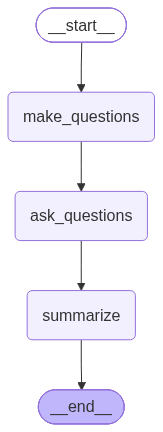

In [7]:
# s -> 질문 생성 -> interrupt -> 모아서 원래 요청을 처리(실습에서는 모으기) -> end
llm = ChatGoogleGenerativeAI(model=MODEL_NAME)

class QuestionState(TypedDict):
    request: str
    message: str
    questions: list
    answer: list
    result: str

class Question(BaseModel):
    question: str = Field(description="질문")
    options: list[str] = Field(description="질문에 대한 선택지.")


class Questions(BaseModel):
    message: str = Field(description="질문에 대한 안내 메시지. ex) 여행 스타일에 맞춰서 계획을 짜드릴게요! 몇 가지만 먼저 여쭤볼게요.")
    questions: list[Question]

def make_questions(state: QuestionState):
    request = state['request']
    response = llm.with_structured_output(Questions).invoke(f'{request}를 처리하기 위해 유저에게 요청할 질문을 만들어줘.')
    return {
        'message' : response.message,
        'questions': [q.model_dump() for q in response.questions]
    }


def ask_questions(state: QuestionState):
    answer = interrupt({
        'message': state['message'],
        'questions' : state['questions']
    })
    return {
        'answer' : answer['answer']
    }

def summarize(state: QuestionState):
    result = llm.invoke(f"""사용자 요청 : {state['request']}
                        사용자에게 받은 추가 정보 : {state['answer']}
사용자의 요청에 대해서 응답해줘.""")

    return {
        'result' : result.text
    }

builder = StateGraph(QuestionState)
builder.add_node('make_questions', make_questions)
builder.add_node('ask_questions', ask_questions)
builder.add_node('summarize', summarize)

builder.add_edge(START, 'make_questions')
builder.add_edge('make_questions', 'ask_questions')
builder.add_edge('ask_questions', 'summarize')
builder.add_edge('summarize', END)

question_graph = builder.compile(checkpointer=MemorySaver())

display(Image(question_graph.get_graph().draw_mermaid_png()))

In [9]:
config = {"configurable": {"thread_id": "session-2"}}
result = question_graph.invoke({"request" : "여행 계획을 짤꺼야. 나한테 맞는 여행계획을 추천해줘."}, config=config)

request = result["__interrupt__"][0].value
print(f"안내 메시지: {request['message']}")
# print(f"질문: {request['questions']}")
answer = []

for question in request['questions']:
    
    print(question['question'], question['options'])
    # answer에 [(질문, 답변)]의 형태로 담는다.
    answer.append((question['question'], input('너의 선택을 입력하세요.')))

안내 메시지: 고객님의 취향에 딱 맞는 맞춤형 여행 계획을 세워드릴게요! 아래 몇 가지 질문에 답변해 주세요.
누구와 함께 떠나는 여행인가요? ['혼자', '친구', '연인/배우자', '아이 동반 가족', '부모님 동반 가족']
선호하는 여행 스타일은 무엇인가요? ['여유로운 휴양과 힐링', '유명 관광지와 핫플 방문', '맛집 탐방과 카페 투어', '액티비티와 레저 스포츠']
희망하는 여행 기간은 얼마인가요? ['당일치기', '1박 2일 ~ 2박 3일', '3박 4일 ~ 4박 5일', '일주일 이상']
어떤 분위기의 여행지를 선호하시나요? ['푸른 바다가 있는 곳', '공기 좋은 산/자연', '활기찬 도심', '고즈넉한 역사/문화도시']


In [10]:
print(answer)

[('누구와 함께 떠나는 여행인가요?', '혼자'), ('선호하는 여행 스타일은 무엇인가요?', '여유로운 휴양과 힐링'), ('희망하는 여행 기간은 얼마인가요?', '당일치기'), ('어떤 분위기의 여행지를 선호하시나요?', '활기찬 도심')]


In [11]:
# 다시 graph를 invoke()
response = question_graph.invoke(Command(resume={'answer' : answer}), config=config)


AttributeError: 'dict' object has no attribute 'result'

In [12]:
print(response['result'])

제공해주신 정보를 바탕으로 **혼자서도 부담 없이, 활기찬 도심의 에너지를 느끼면서 여유롭게 힐링할 수 있는 당일치기 여행 코스**를 추천해 드립니다.

도심의 세련되고 활기찬 분위기와 자연이 주는 평온함을 모두 누릴 수 있는 **'서울 성수동 & 서울숲 코스'**입니다. 

---

### 🌿 추천 여행지: [서울] 도심 속 초록빛 휴식, '성수 & 서울숲' 당일치기

활기찬 팝업스토어와 트렌디한 거리(도심 분위기), 그리고 울창한 숲과 한강(힐링)이 공존하여 혼자서 여유로운 호흡으로 즐기기에 최적의 장소입니다.

#### 📍 추천 일정 (타임라인)

*   **11:00 AM | [힐링] 서울숲 산책 & 숲멍**
    *   오전의 비교적 한적한 서울숲을 천천히 걸어보세요. 거대한 나무들 사이를 산책하거나 거울연못 근처 벤치에 앉아 음악을 들으며 '숲멍'을 즐기기에 좋습니다.
*   **12:30 PM | [도심] 성수동 맛집에서 혼밥**
    *   성수동은 바 테이블이 잘 되어 있어 혼자 방문하기 좋은 맛집이 많습니다. (추천: 정갈한 일식 덮밥, 1인 솥밥, 혹은 감성적인 브런치 카페)
*   **02:00 PM | [힐링&문화] 감성 카페 & 독립서점 탐방**
    *   채광이 좋고 통창이 있는 대형 카페나 정원이 있는 성수동 카페에서 커피 한 잔의 여유를 즐겨보세요.
    *   근처의 작은 독립서점(예: 성수 '문학살롱 초록')이나 소품샵을 둘러보며 혼자만의 취향을 찾는 시간을 가집니다.
*   **04:00 PM | [도심] 활기찬 성수동 거리 & 팝업스토어 구경**
    *   성수동 연무장길을 중심으로 펼쳐진 화려하고 활기찬 팝업스토어와 플래그십 스토어를 구경하며 도심의 생기 있는 에너지를 충전합니다.
*   **06:30 PM | [힐링] 뚝섬 한강공원 노을 & 야경 감상**
    *   여행의 마무리는 성수동과 연결된 뚝섬 한강공원에서 합니다. 돗자리를 빌리거나 벤치에 앉아 한강 너머로 지는 노을과 도심의 야경을 바라보며 당